<a href="https://colab.research.google.com/github/Tevoh1/Learning_Repository-Tevoh/blob/Student_Performance1/Student_performance1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#Decision Tree to predict student performances
import pandas as pd
import numpy as np
student_mat = pd.read_csv('student-mat.csv', delimiter=';')

print(student_mat.columns)

print(len(student_mat))


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
395


In [32]:
student_por_raw = pd.read_csv('student-por.csv', delimiter=';')

student_por = student_por_raw.dropna()
print(student_por.columns)

print(len(student_por)) #np.nan_to_num(student_por_raw)



Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
649


In [134]:
#y = student_por['G3'] #final grade

#mean_G = pd.DataFrame()
student_por['mean_G'] = student_por[['G1', 'G2']].mean(axis=1)


features = ['mean_G', 'absences','failures','schoolsup','famsup','paid','activities','school','nursery','higher','internet','romantic']

X = student_por[features]

print(X)

     mean_G  absences  failures schoolsup famsup paid activities school  \
0       5.5         4         0       yes     no   no         no     GP   
1      10.0         2         0        no    yes   no         no     GP   
2      12.5         6         0       yes     no   no         no     GP   
3      14.0         0         0        no    yes   no        yes     GP   
4      12.0         0         0        no    yes   no         no     GP   
..      ...       ...       ...       ...    ...  ...        ...    ...   
644    10.5         4         1        no     no   no        yes     MS   
645    15.0         4         0        no    yes   no         no     MS   
646    11.5         6         0        no     no   no        yes     MS   
647    10.0         6         0        no     no   no         no     MS   
648    10.5         4         0        no     no   no         no     MS   

    nursery higher internet romantic  
0       yes    yes       no       no  
1        no    yes   

In [135]:
y=student_por['G3']
print(y)

0      11
1      11
2      12
3      14
4      13
       ..
644    10
645    16
646     9
647    10
648    11
Name: G3, Length: 649, dtype: int64


In [136]:
# Changing sex values from str to int

X['school'] = X['school'].map({'GP': 0, 'MS': 1})
X['schoolsup'] = X['schoolsup'].map({'yes': 0, 'no': 1})
X['famsup'] = X['famsup'].map({'yes': 0, 'no': 1})
X['paid'] = X['paid'].map({'yes': 0, 'no': 1})
X['activities'] = X['activities'].map({'yes': 0, 'no': 1})
X['nursery'] = X['nursery'].map({'yes': 0, 'no': 1})
X['higher'] = X['higher'].map({'yes': 0, 'no': 1})
X['internet'] = X['internet'].map({'yes': 0, 'no': 1})
X['romantic'] = X['romantic'].map({'yes': 0, 'no': 1})
#X['famsize'] = X['famsize'].map({'LE3': 0, 'GT3': 1})
#X['Embarked'] = X['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})



X_train = X[:500]
X_test = X[500:]

y_train = y[:500]
y_test = y[500:]




<ipython-input-136-f2f47b8fa77e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['school'] = X['school'].map({'GP': 0, 'MS': 1})
<ipython-input-136-f2f47b8fa77e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['schoolsup'] = X['schoolsup'].map({'yes': 0, 'no': 1})
<ipython-input-136-f2f47b8fa77e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

In [148]:
from sklearn.tree import DecisionTreeRegressor

student_perform_model = DecisionTreeRegressor(max_leaf_nodes=6, random_state=1)
student_perform_model.fit(X_train, y_train)

DecisionTreeRegressor(max_leaf_nodes=6, random_state=1)

In [149]:
#predict new y from test values
y_predict = student_perform_model.predict(X_test)
print(y_predict)



[ 7.75862069 13.13868613  9.87850467 15.2295082  13.13868613 11.6147541
  9.87850467 11.6147541   9.87850467 16.88636364 16.88636364  9.87850467
  7.75862069  7.75862069  7.75862069  9.87850467 15.2295082  15.2295082
  7.75862069  7.75862069  7.75862069  9.87850467  7.75862069  7.75862069
  7.75862069 15.2295082  13.13868613  9.87850467  9.87850467 11.6147541
  9.87850467  9.87850467  7.75862069 15.2295082  11.6147541   9.87850467
 13.13868613 13.13868613 11.6147541   9.87850467  9.87850467  9.87850467
 11.6147541   9.87850467 11.6147541   9.87850467 15.2295082  11.6147541
 11.6147541  16.88636364 13.13868613 13.13868613  9.87850467 11.6147541
 11.6147541  13.13868613  9.87850467  7.75862069 11.6147541  13.13868613
  9.87850467  9.87850467 13.13868613  7.75862069  9.87850467  9.87850467
  7.75862069  7.75862069  9.87850467  7.75862069  7.75862069  9.87850467
  7.75862069  7.75862069  9.87850467 11.6147541   9.87850467  9.87850467
  9.87850467  9.87850467  9.87850467  7.75862069  7.7586

In [150]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_predict)
print(mae)

1.37344344597651


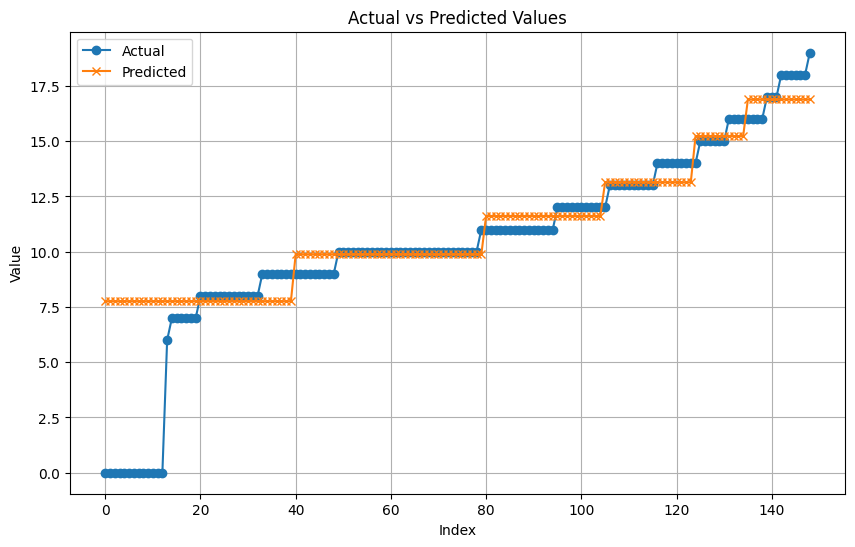

'\n# Custom validation: check if real values are within [pred - mae, pred + mae)\ncorrect = ((y_test >= (y_predict - mae)) & (y_test <= (y_predict + mae))).sum()\ntotal = len(y_test)\naccuracy_percentage = (correct / total) * 100\n'

In [151]:
import matplotlib.pyplot as plt
#import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.tree import DecisionTreeRegressor

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test.sort_values().values, label='Actual', marker='o')
plt.plot(pd.Series(y_predict).sort_values().values, label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

'''
# Custom validation: check if real values are within [pred - mae, pred + mae)
correct = ((y_test >= (y_predict - mae)) & (y_test <= (y_predict + mae))).sum()
total = len(y_test)
accuracy_percentage = (correct / total) * 100
'''



In [152]:

# Custom validation: check if real values are within [pred - mae, pred + mae)
correct = ((y_test >= (y_predict - (mae))) & (y_test <= (y_predict + (mae)))).sum()
total = len(y_test)
accuracy_percentage = (correct / total) * 100

print(f"Custom Accuracy: {accuracy_percentage:.2f}% (within ±MAE)")

Custom Accuracy: 78.52% (within ±MAE)
